<a href="https://colab.research.google.com/github/Noga-66/TWeets-_Sentiment_analysis/blob/main/Tweet_Sentiment_RNN_LSTM_GRU_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tweet Sentiment Analysis



## 1) Install & Import Libraries

In [ ]:

import re
import string
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, callbacks

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 2) Load the Data

In [ ]:
df = pd.read_csv("Tweets.csv")
print("Shape:", df.shape)
df.head()


Shape: (27481, 4)


,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [ ]:

print(df.isna().sum())
df = df.dropna(subset=["text"]).reset_index(drop=True)
print("Shape after dropping NaN:", df.shape)


textID           0
text             1
selected_text    1
sentiment        0
dtype: int64
Shape after dropping NaN: (27480, 4)


## 3) Exploratory Data Analysis (EDA)

/tmp/ipykernel_11884/445849635.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sentiment", order=df["sentiment"].value_counts().index, palette="viridis")


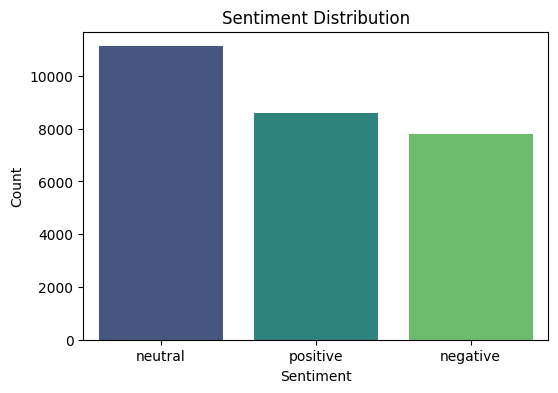

sentiment
neutral     40.454876
positive    31.229985
negative    28.315138
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="sentiment", order=df["sentiment"].value_counts().index, palette="viridis")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

print(df["sentiment"].value_counts(normalize=True) * 100)


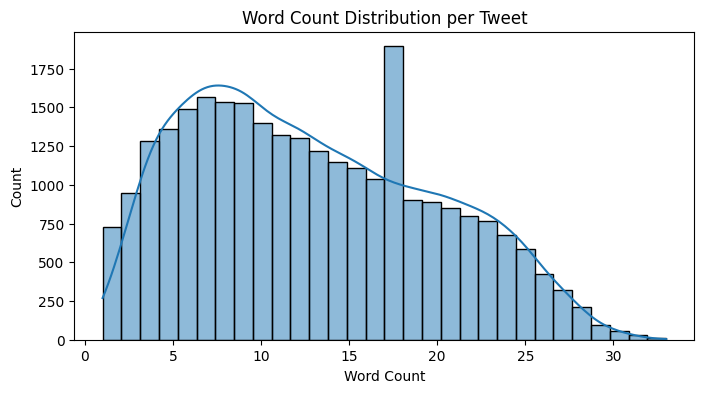

count    27480.000000
mean        12.902875
std          6.925938
min          1.000000
25%          7.000000
50%         12.000000
75%         18.000000
max         33.000000
Name: word_count, dtype: float64


In [ ]:
df["word_count"] = df["text"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,4))
sns.histplot(df["word_count"], bins=30, kde=True)
plt.title("Word Count Distribution per Tweet")
plt.xlabel("Word Count")
plt.show()

print(df["word_count"].describe())


## 4) Text Cleaning


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"&\w+;", " ", text)
    text = re.sub(r"#", " ", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text
df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)
print("Shape after cleaning:", df.shape)

df[["text", "clean_text", "sentiment"]].sample(10, random_state=SEED)


Shape after cleaning: (27476, 6)


,text,clean_text,sentiment
17489,im nervous :/ i want to gimme a bear hug,im nervous i want to gimme a bear hug,neutral
12146,I will take lots of pics! it is really pretty...,i will take lots of pics it is really pretty t...,positive
1456,Watching the film Real Women Have Curves Why ...,watching the film real women have curves why a...,neutral
9469,Feeeel like ima die! Now on my way to rainfore...,feeeel like ima die now on my way to rainfores...,negative
7745,"hi there, nice to meet you",hi there nice to meet you,positive
22994,i work in youth justice,i work in youth justice,neutral
12421,Why am I limited to only being able to sync wi...,why am i limited to only being able to sync wi...,negative
17925,it was apparently a request by the guests,it was apparently a request by the guests,neutral
2805,So bored... need more people for rsmv !! jage...,so bored need more people for rsmv jagex doesn...,negative
10610,_ omg and you never would believe what we did....,omg and you never would believe what we did ah...,positive


## 5) Label Encoding

In [ ]:
le = LabelEncoder()
df["label"] = le.fit_transform(df["sentiment"])
print(dict(zip(le.classes_, le.transform(le.classes_))))


{'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


## 6) Train / Validation / Test Split

In [ ]:
X = df["clean_text"].values
y = df["label"].values
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (19233,) Val: (4121,) Test: (4122,)


## 7) Tokenization and Padding

In [ ]:
VOCAB_SIZE = 15000
MAXLEN = 40

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAXLEN, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAXLEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAXLEN, padding="post", truncating="post")

vocab_used = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)
print("Vocabulary size found:", len(tokenizer.word_index))
print("Vocabulary used:", vocab_used)
print("Example padded sequence:", X_train_pad[0])


Vocabulary size found: 19572
Vocabulary used: 15000
Example padded sequence: [5474 1129    4 1055    9    4 3512 8056 3513   12 8057 1975    9 5475
 5475    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0]


In [ ]:
NUM_CLASSES = len(le.classes_)

y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)
class_weights_arr = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weights = dict(enumerate(class_weights_arr))
print("Class weights:", class_weights)


Class weights: {0: np.float64(1.1771942710246053), 1: np.float64(0.8240359897172237), 2: np.float64(1.0672548693191277)}


## 8) Building the Models


In [ ]:
EMBEDDING_DIM = 128

def build_model(rnn_type="lstm"):
    inputs = layers.Input(shape=(MAXLEN,))
    x = layers.Embedding(input_dim=vocab_used, output_dim=EMBEDDING_DIM, mask_zero=True)(inputs)

    if rnn_type == "simplernn":
        x = layers.Bidirectional(layers.SimpleRNN(64, return_sequences=True))(x)
        x = layers.Bidirectional(layers.SimpleRNN(32))(x)
    elif rnn_type == "lstm":
        x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
        x = layers.Bidirectional(layers.LSTM(32))(x)
    elif rnn_type == "gru":
        x = layers.Bidirectional(layers.GRU(64, return_sequences=True))(x)
        x = layers.Bidirectional(layers.GRU(32))(x)
    else:
        raise ValueError("Unknown rnn_type")

    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = models.Model(inputs, outputs, name=f"{rnn_type}_model")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

build_model("lstm").summary()


Model: "lstm_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 40, 128)   │  1,920,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 40)        │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 40, 128)   │     98,816 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 64)        │     41,216 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        195 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,064,387 (7.88 MB)

 Trainable params: 2,064,387 (7.88 MB)

 Non-trainable params: 0 (0.00 B)

## 9) Training the Models

In [ ]:
EPOCHS = 25
BATCH_SIZE = 64

def get_callbacks(name):
    return [
        callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
        callbacks.ModelCheckpoint(f"best_{name}.keras", monitor="val_accuracy", save_best_only=True),
    ]

histories = {}
models_dict = {}

for rnn_type in ["simplernn", "lstm", "gru"]:
    print("="*60)
    print(f"Training {rnn_type.upper()} model...")
    print("="*60)
    model = build_model(rnn_type)
    hist = model.fit(
        X_train_pad, y_train_cat,
        validation_data=(X_val_pad, y_val_cat),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weights,
        callbacks=get_callbacks(rnn_type),
        verbose=1,
    )
    histories[rnn_type] = hist
    models_dict[rnn_type] = model


Training SIMPLERNN model...
Epoch 1/25
301/301 ━━━━━━━━━━━━━━━━━━━━ 40s 110ms/step - accuracy: 0.4773 - loss: 0.9810 - val_accuracy: 0.6273 - val_loss: 0.8031 - learning_rate: 0.0010
Epoch 2/25
301/301 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - accuracy: 0.7141 - loss: 0.6610 - val_accuracy: 0.6588 - val_loss: 0.8131 - learning_rate: 0.0010
Epoch 3/25
301/301 ━━━━━━━━━━━━━━━━━━━━ 32s 105ms/step - accuracy: 0.8346 - loss: 0.4240 - val_accuracy: 0.6423 - val_loss: 1.0200 - learning_rate: 0.0010
Epoch 4/25
301/301 ━━━━━━━━━━━━━━━━━━━━ 41s 106ms/step - accuracy: 0.9217 - loss: 0.2229 - val_accuracy: 0.6426 - val_loss: 1.2851 - learning_rate: 5.0000e-04
Epoch 5/25
301/301 ━━━━━━━━━━━━━━━━━━━━ 33s 111ms/step - accuracy: 0.9569 - loss: 0.1277 - val_accuracy: 0.6479 - val_loss: 1.5082 - learning_rate: 5.0000e-04
Epoch 6/25
301/301 ━━━━━━━━━━━━━━━━━━━━ 32s 107ms/step - accuracy: 0.9773 - loss: 0.0722 - val_accuracy: 0.6430 - val_loss: 1.6427 - learning_rate: 2.5000e-04
Training LSTM model...
Epoch 1

## 10) Training Curves

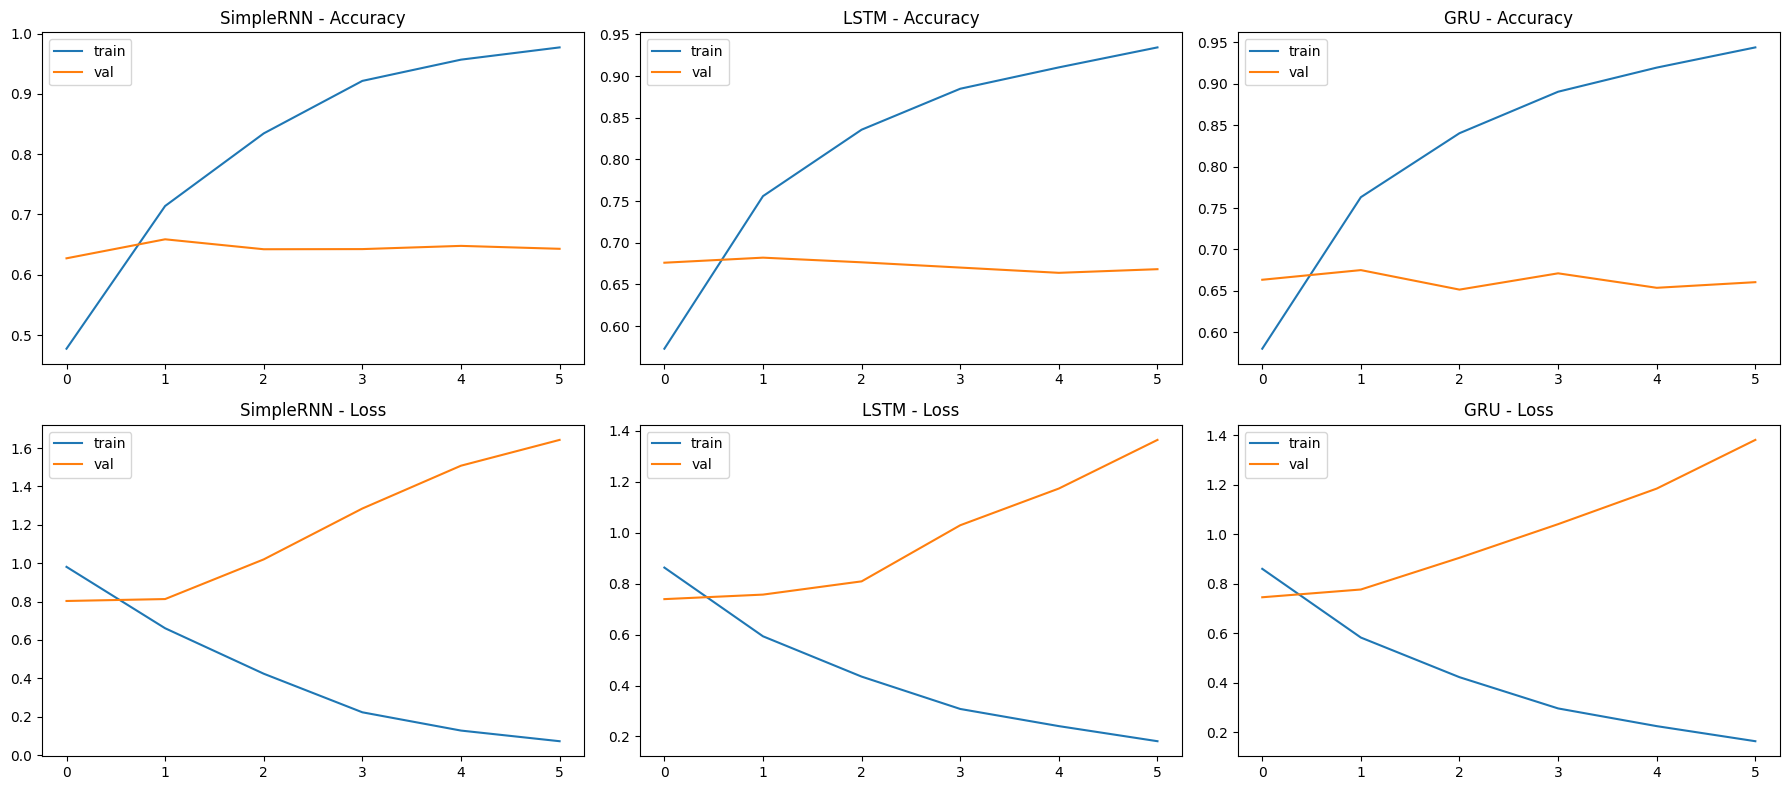

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
names = {"simplernn": "SimpleRNN", "lstm": "LSTM", "gru": "GRU"}

for i, rnn_type in enumerate(["simplernn", "lstm", "gru"]):
    h = histories[rnn_type].history
    axes[0, i].plot(h["accuracy"], label="train")
    axes[0, i].plot(h["val_accuracy"], label="val")
    axes[0, i].set_title(f"{names[rnn_type]} - Accuracy")
    axes[0, i].legend()

    axes[1, i].plot(h["loss"], label="train")
    axes[1, i].plot(h["val_loss"], label="val")
    axes[1, i].set_title(f"{names[rnn_type]} - Loss")
    axes[1, i].legend()

plt.tight_layout()
plt.show()


## 11) Evaluating the Models on Test Data

In [ ]:
results = {}

for rnn_type in ["simplernn", "lstm", "gru"]:
    model = models_dict[rnn_type]
    loss, acc = model.evaluate(X_test_pad, y_test_cat, verbose=0)
    y_pred = np.argmax(model.predict(X_test_pad, verbose=0), axis=1)

    results[rnn_type] = {
        "test_loss": loss,
        "test_accuracy": acc,
        "y_pred": y_pred,
    }

    print("="*60)
    print(f"{names[rnn_type]} -> Test Accuracy: {acc:.4f} | Test Loss: {loss:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


SimpleRNN -> Test Accuracy: 0.6672 | Test Loss: 0.8045
              precision    recall  f1-score   support

    negative       0.65      0.68      0.66      1167
     neutral       0.65      0.58      0.61      1667
    positive       0.70      0.77      0.73      1288

    accuracy                           0.67      4122
   macro avg       0.67      0.68      0.67      4122
weighted avg       0.67      0.67      0.66      4122

LSTM -> Test Accuracy: 0.6841 | Test Loss: 0.7512
              precision    recall  f1-score   support

    negative       0.70      0.68      0.69      1167
     neutral       0.69      0.57      0.63      1667
    positive       0.67      0.83      0.74      1288

    accuracy                           0.68      4122
   macro avg       0.69      0.69      0.69      4122
weighted avg       0.69      0.68      0.68      4122

GRU -> Test Accuracy: 0.6773 | Test Loss: 0.7600
              precision    recall  f1-score   support

    negative       0.66      

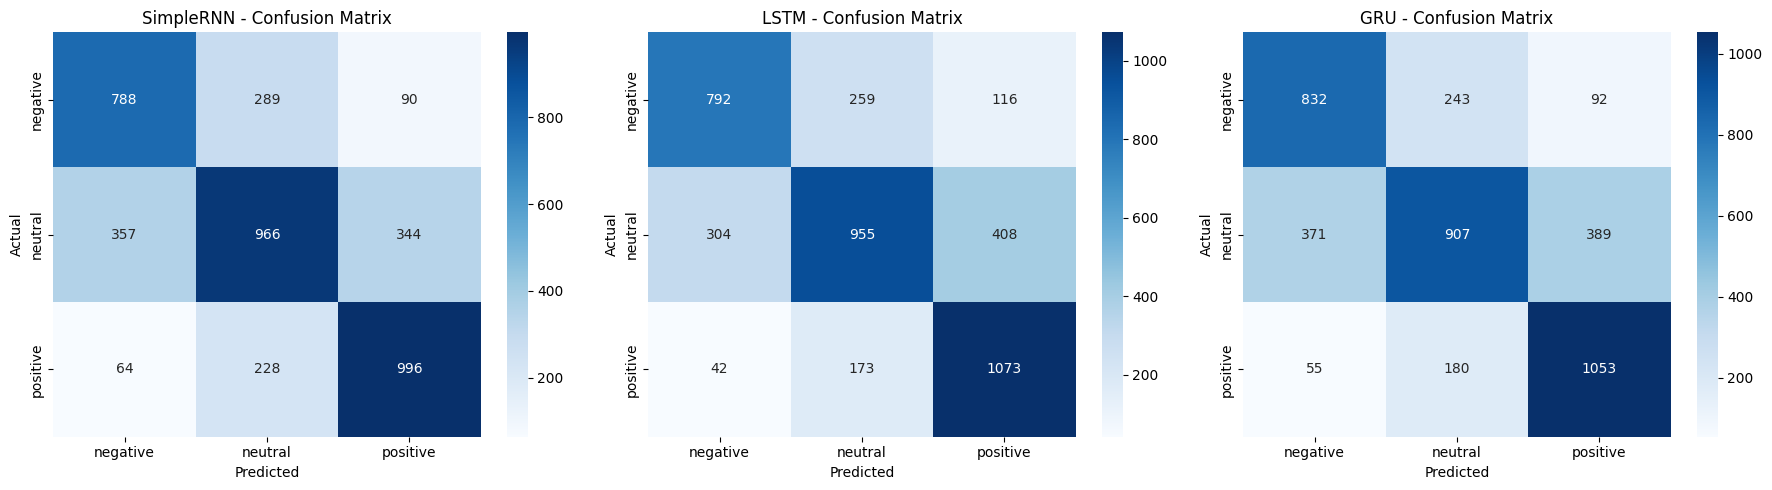

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, rnn_type in enumerate(["simplernn", "lstm", "gru"]):
    cm = confusion_matrix(y_test, results[rnn_type]["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[i])
    axes[i].set_title(f"{names[rnn_type]} - Confusion Matrix")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
plt.tight_layout()
plt.show()


## 12) Final Comparison Between the Three Models

In [ ]:
comparison_df = pd.DataFrame({
    "Model": [names[r] for r in ["simplernn", "lstm", "gru"]],
    "Test Accuracy": [results[r]["test_accuracy"] for r in ["simplernn", "lstm", "gru"]],
    "Test Loss": [results[r]["test_loss"] for r in ["simplernn", "lstm", "gru"]],
})
comparison_df = comparison_df.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
comparison_df


,Model,Test Accuracy,Test Loss
0,LSTM,0.684134,0.751167
1,GRU,0.677341,0.760013
2,SimpleRNN,0.667152,0.804535


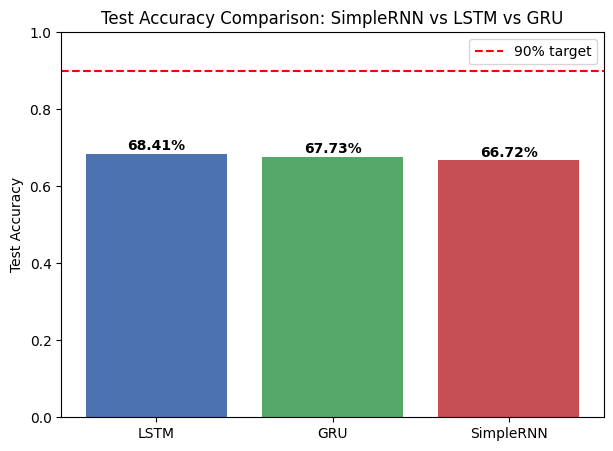

Best model: LSTM -> Test Accuracy: 0.6841338872909546


In [ ]:
plt.figure(figsize=(7,5))
bars = plt.bar(comparison_df["Model"], comparison_df["Test Accuracy"],
               color=["#4C72B0", "#55A868", "#C44E52"])
plt.ylim(0, 1)
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison: SimpleRNN vs LSTM vs GRU")
for bar, acc in zip(bars, comparison_df["Test Accuracy"]):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.01, f"{acc:.2%}", ha="center", fontweight="bold")
plt.axhline(0.90, color="red", linestyle="--", label="90% target")
plt.legend()
plt.show()

best_model_name = comparison_df.iloc[0]["Model"].lower().replace(" ", "")
best_key = [k for k in ["simplernn", "lstm", "gru"] if names[k].lower() == comparison_df.iloc[0]['Model'].lower()][0]
print("Best model:", names[best_key], "-> Test Accuracy:", comparison_df.iloc[0]["Test Accuracy"])


## 13) Saving the Best Model + Tokenizer + Label Encoder

These files will be used later in the web app (Streamlit) for deployment.


In [ ]:
best_model = models_dict[best_key]
best_model.save("sentiment_model.keras")

with open("tokenizer.pickle", "wb") as f:
    pickle.dump(tokenizer, f)

with open("label_encoder.pickle", "wb") as f:
    pickle.dump(le, f)

config = {"maxlen": MAXLEN, "vocab_size": vocab_used, "best_model": names[best_key]}
with open("config.pickle", "wb") as f:
    pickle.dump(config, f)

print("Saved: sentiment_model.keras, tokenizer.pickle, label_encoder.pickle, config.pickle")


Saved: sentiment_model.keras, tokenizer.pickle, label_encoder.pickle, config.pickle


## 14) Quick Test on a New Sentence

In [ ]:
def predict_sentiment(text, model=None, tok=None, label_enc=None, maxlen=MAXLEN):
    model = model or best_model
    tok = tok or tokenizer
    label_enc = label_enc or le

    cleaned = clean_text(text)
    seq = tok.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=maxlen, padding="post", truncating="post")
    probs = model.predict(pad, verbose=0)[0]
    pred_label = label_enc.inverse_transform([np.argmax(probs)])[0]
    return pred_label, dict(zip(label_enc.classes_, probs.round(3)))

for sample in [
    "I love this so much, best day ever!",
    "This is the worst experience I have ever had",
    "I am going to the store later",
]:
    label, probs = predict_sentiment(sample)
    print(f"Text: {sample}\\n -> Sentiment: {label} | Probs: {probs}\\n")


Text: I love this so much, best day ever!\n -> Sentiment: positive | Probs: {'negative': np.float32(0.0), 'neutral': np.float32(0.002), 'positive': np.float32(0.998)}\n
Text: This is the worst experience I have ever had\n -> Sentiment: negative | Probs: {'negative': np.float32(0.948), 'neutral': np.float32(0.041), 'positive': np.float32(0.011)}\n
Text: I am going to the store later\n -> Sentiment: neutral | Probs: {'negative': np.float32(0.081), 'neutral': np.float32(0.883), 'positive': np.float32(0.036)}\n
